In [4]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from openai import OpenAI
from dotenv import load_dotenv
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [5]:
df = pd.read_excel('./las3.18.xlsx')

In [ ]:

nan_columns = df.columns[df.isna().any()].tolist()
print("Columns with NaNs:", nan_columns)

rows_of_users = []
for i,j in df.iterrows():
    sentence  = f"User is an {j['Job_Seniority']} in {j['Job_Function']} from the {j['Parent_Industry']} industry, working in a company with a turnover of {j['Turnover_Range']} and {j['Employees_Range']} employees. Their key areas of interest include {j['aoi_1']}, {j['aoi_2']}, {j['aoi_3']}, {j['aoi_4']}, and {j['aoi_5']}."
    rows_of_users.append(sentence)

load_dotenv()
client = OpenAI()
def batch(iterable, n=100):
    l = len(iterable)
    for ndx in range(0, l, n):
        yield iterable[ndx:min(ndx + n, l)]

all_embeddings = []
for batch_rows in batch(rows_of_users, 100):
    response = client.embeddings.create(
        input=batch_rows,
        model="text-embedding-3-large"
    )
    all_embeddings.extend([item.embedding for item in response.data])



Columns with NaNs: []


In [2]:
#a=pd.DataFrame(all_embeddings)
#a1=a.to_csv("./a.csv",index=False)
scaler = StandardScaler()
openai_embeddings = np.array(all_embeddings)
openai_embeddings_scaled = scaler.fit_transform(openai_embeddings)

pca = PCA(n_components=15)
reduced = pca.fit_transform(openai_embeddings_scaled)

db = DBSCAN(eps=7, min_samples=7)
labels = db.fit_predict(reduced)


print((labels))
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(n_clusters)

NameError: name 'StandardScaler' is not defined

In [1]:
all_embeddings

NameError: name 'all_embeddings' is not defined

In [220]:
df["clusters"] = labels
df.to_excel("db_05_07_07.xlsx")


In [280]:
kmeans = KMeans(n_clusters=23, random_state=42)
labels2 = kmeans.fit_predict(reduced)
clusters=labels2
df["clustersk"] = labels2
df.to_excel("km_23.xlsx")

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from pyod.models.ecod import ECOD
import prince
import plotly.express as px 
from sklearn.decomposition import PCA
print(f"Davies-Bouldin Score: {davies_bouldin_score(reduced, clusters):.3f}")
print(f"Calinski-Harabasz Score: {calinski_harabasz_score(reduced, clusters):.3f}")
print(f"Silhouette Score: {silhouette_score(reduced, clusters):.3f}")


Davies-Bouldin Score: 1.663
Calinski-Harabasz Score: 202.676
Silhouette Score: 0.212


🚀 Starting K-means Optimization...
🔧 Preparing data...
📊 Applied PCA: 3072 → 20 dimensions
📈 Explained variance: 0.799
✅ Data prepared: (2425, 20)
📈 Running Elbow Method...


Elbow Method: 100%|██████████| 15/15 [00:01<00:00, 10.00it/s]


🎯 Auto-detected elbow at K = 6


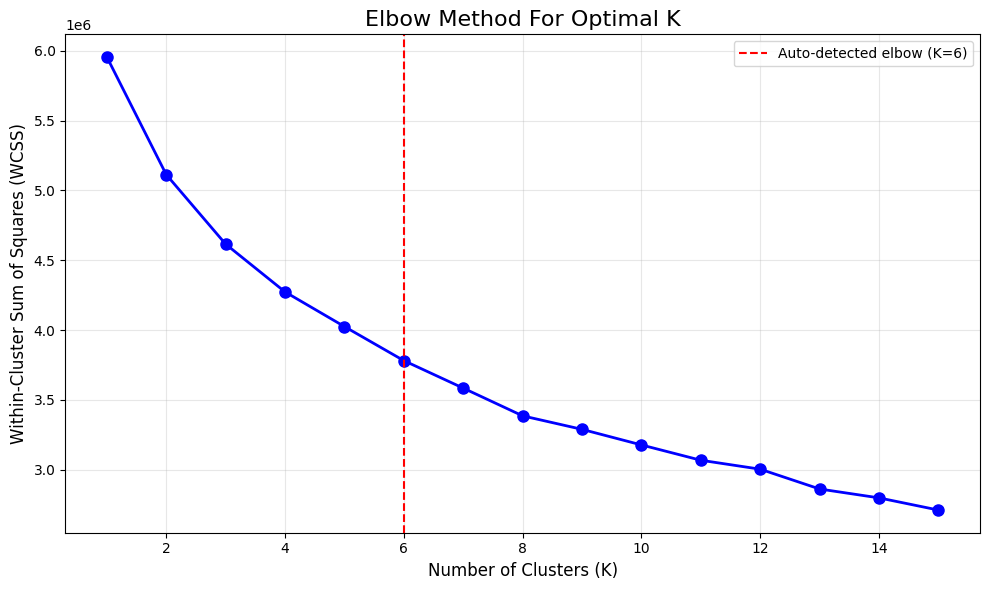

📊 Running Silhouette Analysis...


Silhouette Analysis: 100%|██████████| 14/14 [00:02<00:00,  5.71it/s]


🎯 Best K by Silhouette: 13 (Score: 0.190)


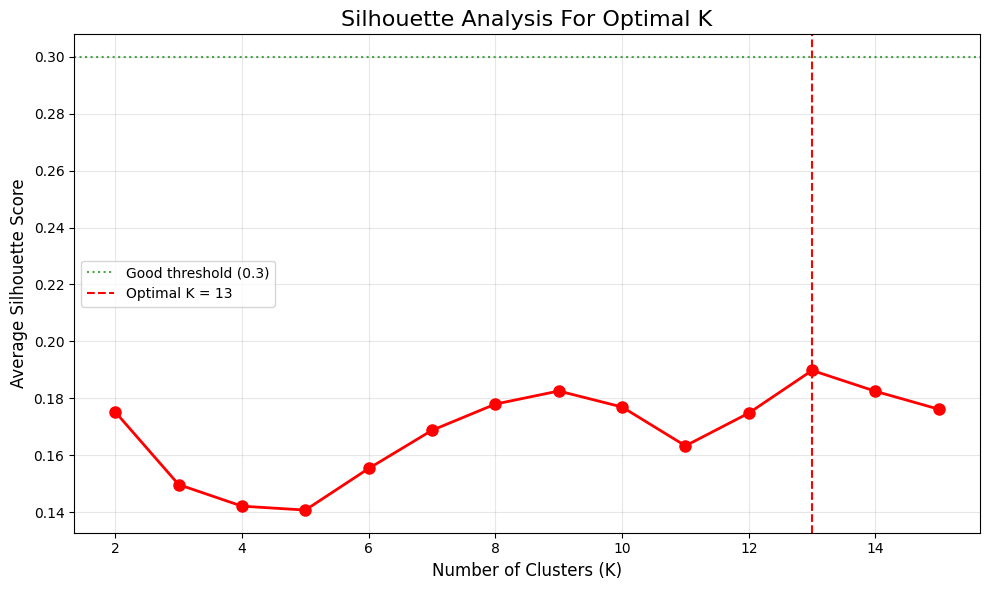

🔍 Running Comprehensive Evaluation...
  K       WCSS   Silhouette   Calinski-H   Davies-B
-------------------------------------------------------


Comprehensive Evaluation:  14%|█▍        | 2/14 [00:00<00:02,  5.03it/s]

  2 5112935.21        0.175       399.24      1.954
  3 4615036.88        0.150       351.71      2.372


Comprehensive Evaluation:  21%|██▏       | 3/14 [00:00<00:02,  4.83it/s]

  4 4272790.28        0.142       317.80      2.187
  5 4018561.37        0.153       291.59      1.973


...

 13 2861185.53        0.190       217.37      1.684


Comprehensive Evaluation:  93%|█████████▎| 13/14 [00:04<00:00,  1.84it/s]

 14 2755675.08        0.178       215.35      1.665


Comprehensive Evaluation: 100%|██████████| 14/14 [00:05<00:00,  2.79it/s]

 15 2677436.07        0.196       210.75      1.595

🏆 OPTIMIZATION RESULTS:
Criterion            K   Score     
-----------------------------------
Silhouette           15  0.196     
Calinski-Harabasz    2   399.24    
Davies-Bouldin       15  1.595     
Composite            2   0.716     

🎯 RECOMMENDED: K = 2 (Composite Score)


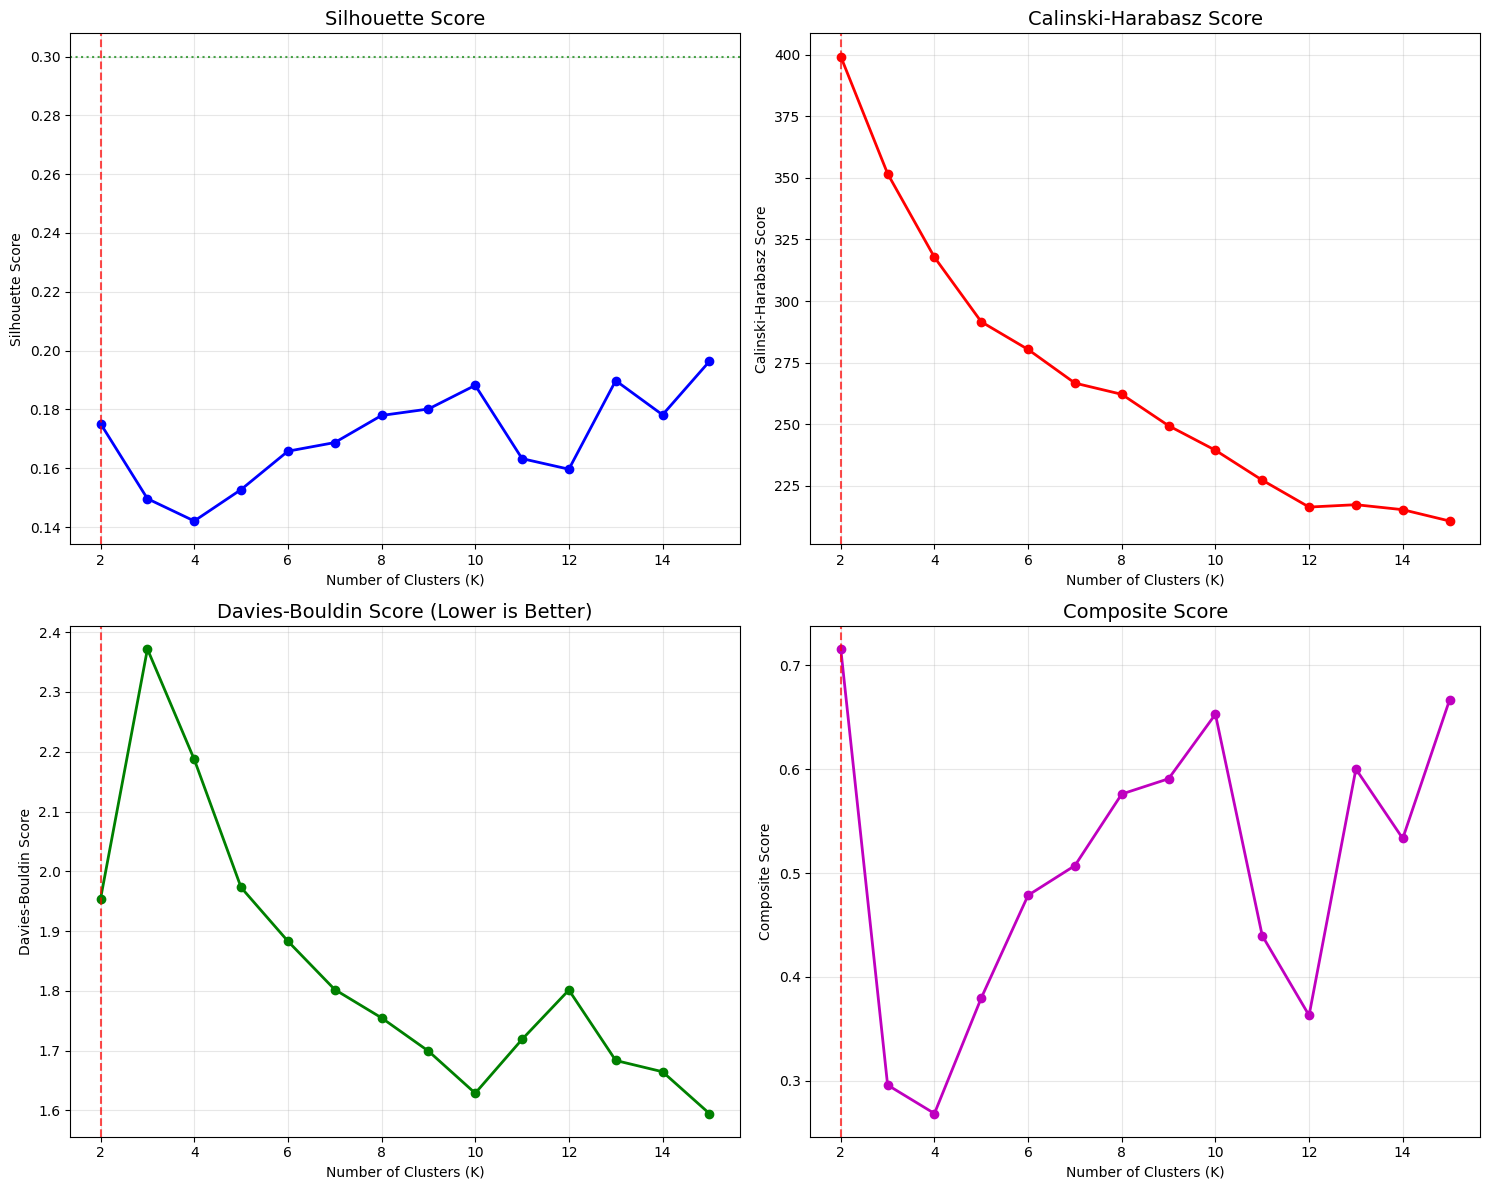


✅ FINAL K-MEANS MODEL:
Optimal K: 2
Silhouette Score: 0.175
Calinski-Harabasz Score: 399.24
Davies-Bouldin Score: 1.954
Total samples: 2425
Cluster sizes: [1872  553]
Optimal number of clusters: 2
Cluster assignments: [1 0 1 ... 0 1 0]
     k  silhouette  calinski_harabasz  davies_bouldin
0    2    0.175154         399.239310        1.954437
1    3    0.149643         351.714636        2.371676
2    4    0.142056         317.795179        2.187142
3    5    0.152749         291.593285        1.972948
4    6    0.165796         280.365403        1.883086
5    7    0.168732         266.715257        1.802233
6    8    0.177949         262.167897        1.754873
7    9    0.180138         249.416917        1.699350
8   10    0.188190         239.460685        1.628861
9   11    0.163266         227.324118        1.718900
10  12    0.159676         216.406442        1.801410
11  13    0.189790         217.370207        1.683618
12  14    0.178165         215.346627        1.664747
13  15 

In [237]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.decomposition import PCA
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Optional: Install kneed for automatic elbow detection
# pip install kneed
try:
    from kneed import KneeLocator
    KNEED_AVAILABLE = True
except ImportError:
    KNEED_AVAILABLE = False
    print("Note: Install 'kneed' for automatic elbow detection: pip install kneed")

class OptimalKMeans:
    """
    Complete K-means optimization class with multiple evaluation methods
    """
    
    def __init__(self, max_k=15, random_state=42):
        self.max_k = max_k
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.results = []
        self.best_model = None
        self.scaled_data = None
        
    def prepare_data(self, data, apply_pca=False, n_components=None):
        """Prepare and scale data for clustering"""
        print("🔧 Preparing data...")
        
        # Convert to numpy array if needed
        if isinstance(data, (list, pd.DataFrame)):
            data = np.array(data)
        
        # Scale the data
        self.scaled_data = self.scaler.fit_transform(data)
        
        # Apply PCA if requested
        if apply_pca and n_components:
            self.pca = PCA(n_components=n_components, random_state=self.random_state)
            self.scaled_data = self.pca.fit_transform(self.scaled_data)
            print(f"📊 Applied PCA: {data.shape[1]} → {self.scaled_data.shape[1]} dimensions")
            print(f"📈 Explained variance: {self.pca.explained_variance_ratio_.sum():.3f}")
        
        print(f"✅ Data prepared: {self.scaled_data.shape}")
        return self.scaled_data
    
    def elbow_method(self, plot=True):
        """Find optimal K using elbow method"""
        print("📈 Running Elbow Method...")
        
        wcss = []
        k_range = range(1, self.max_k + 1)
        
        for k in tqdm(k_range, desc="Elbow Method"):
            kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, 
                          random_state=self.random_state)
            kmeans.fit(self.scaled_data)
            wcss.append(kmeans.inertia_)
        
        # Auto-detect elbow if kneed is available
        optimal_k_elbow = None
        if KNEED_AVAILABLE:
            knee_locator = KneeLocator(k_range, wcss, curve='convex', direction='decreasing')
            optimal_k_elbow = knee_locator.knee
            print(f"🎯 Auto-detected elbow at K = {optimal_k_elbow}")
        
        if plot:
            plt.figure(figsize=(10, 6))
            plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
            plt.title('Elbow Method For Optimal K', fontsize=16)
            plt.xlabel('Number of Clusters (K)', fontsize=12)
            plt.ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
            plt.grid(True, alpha=0.3)
            
            if optimal_k_elbow:
                plt.axvline(x=optimal_k_elbow, color='red', linestyle='--', 
                           label=f'Auto-detected elbow (K={optimal_k_elbow})')
                plt.legend()
            
            plt.tight_layout()
            plt.show()
        
        return wcss, optimal_k_elbow
    
    def silhouette_analysis(self, plot=True):
        """Find optimal K using silhouette analysis"""
        print("📊 Running Silhouette Analysis...")
        
        silhouette_scores = []
        k_range = range(2, self.max_k + 1)
        
        for k in tqdm(k_range, desc="Silhouette Analysis"):
            kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, 
                          random_state=self.random_state)
            cluster_labels = kmeans.fit_predict(self.scaled_data)
            silhouette_avg = silhouette_score(self.scaled_data, cluster_labels)
            silhouette_scores.append(silhouette_avg)
        
        optimal_k_sil = k_range[np.argmax(silhouette_scores)]
        best_sil_score = max(silhouette_scores)
        
        print(f"🎯 Best K by Silhouette: {optimal_k_sil} (Score: {best_sil_score:.3f})")
        
        if plot:
            plt.figure(figsize=(10, 6))
            plt.plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
            plt.title('Silhouette Analysis For Optimal K', fontsize=16)
            plt.xlabel('Number of Clusters (K)', fontsize=12)
            plt.ylabel('Average Silhouette Score', fontsize=12)
            plt.grid(True, alpha=0.3)
            plt.axhline(y=0.3, color='green', linestyle=':', alpha=0.7, 
                       label='Good threshold (0.3)')
            plt.axvline(x=optimal_k_sil, color='red', linestyle='--', 
                       label=f'Optimal K = {optimal_k_sil}')
            plt.legend()
            plt.tight_layout()
            plt.show()
        
        return silhouette_scores, optimal_k_sil
    
    def comprehensive_evaluation(self):
        """Comprehensive evaluation using all metrics"""
        print("🔍 Running Comprehensive Evaluation...")
        
        self.results = []
        k_range = range(2, self.max_k + 1)
        
        print(f"{'K':>3} {'WCSS':>10} {'Silhouette':>12} {'Calinski-H':>12} {'Davies-B':>10}")
        print("-" * 55)
        
        for k in tqdm(k_range, desc="Comprehensive Evaluation"):
            # Fit K-means
            kmeans = KMeans(
                n_clusters=k, 
                init='k-means++',
                n_init=20,  # More runs for stability
                max_iter=300,
                random_state=self.random_state
            )
            cluster_labels = kmeans.fit_predict(self.scaled_data)
            
            # Calculate all metrics
            wcss = kmeans.inertia_
            sil_score = silhouette_score(self.scaled_data, cluster_labels)
            cal_score = calinski_harabasz_score(self.scaled_data, cluster_labels)
            dbi_score = davies_bouldin_score(self.scaled_data, cluster_labels)
            
            # Store results
            result = {
                'k': k,
                'wcss': wcss,
                'silhouette': sil_score,
                'calinski_harabasz': cal_score,
                'davies_bouldin': dbi_score,
                'kmeans_model': kmeans,
                'cluster_labels': cluster_labels
            }
            self.results.append(result)
            
            print(f"{k:>3} {wcss:>10.2f} {sil_score:>12.3f} {cal_score:>12.2f} {dbi_score:>10.3f}")
        
        return self.results
    
    def find_optimal_k(self):
        """Find optimal K using multiple criteria"""
        if not self.results:
            self.comprehensive_evaluation()
        
        # Find best K by different criteria
        best_silhouette = max(self.results, key=lambda x: x['silhouette'])
        best_calinski = max(self.results, key=lambda x: x['calinski_harabasz'])
        best_davies = min(self.results, key=lambda x: x['davies_bouldin'])
        
        # Composite score (normalized)
        sil_scores = [r['silhouette'] for r in self.results]
        cal_scores = [r['calinski_harabasz'] for r in self.results]
        dbi_scores = [r['davies_bouldin'] for r in self.results]
        
        # Normalize scores (0-1 range)
        sil_norm = [(s - min(sil_scores)) / (max(sil_scores) - min(sil_scores)) for s in sil_scores]
        cal_norm = [(s - min(cal_scores)) / (max(cal_scores) - min(cal_scores)) for s in cal_scores]
        dbi_norm = [1 - (s - min(dbi_scores)) / (max(dbi_scores) - min(dbi_scores)) for s in dbi_scores]
        
        # Calculate composite scores
        for i, result in enumerate(self.results):
            result['composite_score'] = (sil_norm[i] + cal_norm[i] + dbi_norm[i]) / 3
        
        best_composite = max(self.results, key=lambda x: x['composite_score'])
        
        print(f"\n🏆 OPTIMIZATION RESULTS:")
        print(f"{'Criterion':<20} {'K':<3} {'Score':<10}")
        print("-" * 35)
        print(f"{'Silhouette':<20} {best_silhouette['k']:<3} {best_silhouette['silhouette']:<10.3f}")
        print(f"{'Calinski-Harabasz':<20} {best_calinski['k']:<3} {best_calinski['calinski_harabasz']:<10.2f}")
        print(f"{'Davies-Bouldin':<20} {best_davies['k']:<3} {best_davies['davies_bouldin']:<10.3f}")
        print(f"{'Composite':<20} {best_composite['k']:<3} {best_composite['composite_score']:<10.3f}")
        
        # Recommend best overall
        self.best_model = best_composite
        print(f"\n🎯 RECOMMENDED: K = {self.best_model['k']} (Composite Score)")
        
        return self.best_model
    
    def plot_all_metrics(self):
        """Plot all evaluation metrics"""
        if not self.results:
            self.comprehensive_evaluation()
        
        k_values = [r['k'] for r in self.results]
        sil_scores = [r['silhouette'] for r in self.results]
        cal_scores = [r['calinski_harabasz'] for r in self.results]
        dbi_scores = [r['davies_bouldin'] for r in self.results]
        composite_scores = [r['composite_score'] for r in self.results]
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 12))
        
        # Silhouette Score
        axes[0,0].plot(k_values, sil_scores, 'bo-', linewidth=2)
        axes[0,0].set_title('Silhouette Score', fontsize=14)
        axes[0,0].set_xlabel('Number of Clusters (K)')
        axes[0,0].set_ylabel('Silhouette Score')
        axes[0,0].grid(True, alpha=0.3)
        axes[0,0].axhline(y=0.3, color='green', linestyle=':', alpha=0.7)
        
        # Calinski-Harabasz Score
        axes[0,1].plot(k_values, cal_scores, 'ro-', linewidth=2)
        axes[0,1].set_title('Calinski-Harabasz Score', fontsize=14)
        axes[0,1].set_xlabel('Number of Clusters (K)')
        axes[0,1].set_ylabel('Calinski-Harabasz Score')
        axes[0,1].grid(True, alpha=0.3)
        
        # Davies-Bouldin Score (lower is better)
        axes[1,0].plot(k_values, dbi_scores, 'go-', linewidth=2)
        axes[1,0].set_title('Davies-Bouldin Score (Lower is Better)', fontsize=14)
        axes[1,0].set_xlabel('Number of Clusters (K)')
        axes[1,0].set_ylabel('Davies-Bouldin Score')
        axes[1,0].grid(True, alpha=0.3)
        
        # Composite Score
        axes[1,1].plot(k_values, composite_scores, 'mo-', linewidth=2)
        axes[1,1].set_title('Composite Score', fontsize=14)
        axes[1,1].set_xlabel('Number of Clusters (K)')
        axes[1,1].set_ylabel('Composite Score')
        axes[1,1].grid(True, alpha=0.3)
        
        # Highlight best K
        if self.best_model:
            best_k = self.best_model['k']
            for ax in axes.flat:
                ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7)
        
        plt.tight_layout()
        plt.show()
    
    def get_final_model(self, k=None):
        """Get final optimized K-means model"""
        if k is None:
            if self.best_model is None:
                self.find_optimal_k()
            k = self.best_model['k']
        
        # Create final model with optimal parameters
        final_kmeans = KMeans(
            n_clusters=k,
            init='k-means++',
            n_init=30,  # More runs for final model
            max_iter=300,
            tol=1e-4,
            random_state=self.random_state
        )
        
        # Fit and get final results
        final_labels = final_kmeans.fit_predict(self.scaled_data)
        
        # Calculate final metrics
        final_sil = silhouette_score(self.scaled_data, final_labels)
        final_cal = calinski_harabasz_score(self.scaled_data, final_labels)
        final_dbi = davies_bouldin_score(self.scaled_data, final_labels)
        
        print(f"\n✅ FINAL K-MEANS MODEL:")
        print(f"Optimal K: {k}")
        print(f"Silhouette Score: {final_sil:.3f}")
        print(f"Calinski-Harabasz Score: {final_cal:.2f}")
        print(f"Davies-Bouldin Score: {final_dbi:.3f}")
        print(f"Total samples: {len(self.scaled_data)}")
        print(f"Cluster sizes: {np.bincount(final_labels)}")
        
        return final_kmeans, final_labels

# Convenience function for quick optimization
def find_optimal_kmeans(data, max_k=15, apply_pca=False, n_components=None, 
                       plot_results=True, random_state=42):
    """
    Quick function to find optimal K-means configuration
    
    Parameters:
    - data: Your input data (embeddings, features, etc.)
    - max_k: Maximum number of clusters to test
    - apply_pca: Whether to apply PCA for dimensionality reduction
    - n_components: Number of PCA components (if apply_pca=True)
    - plot_results: Whether to show plots
    - random_state: Random state for reproducibility
    
    Returns:
    - optimal_kmeans: Fitted K-means model with optimal K
    - cluster_labels: Cluster assignments
    - optimizer: OptimalKMeans object for detailed analysis
    """
    
    print("🚀 Starting K-means Optimization...")
    
    # Initialize optimizer
    optimizer = OptimalKMeans(max_k=max_k, random_state=random_state)
    
    # Prepare data
    optimizer.prepare_data(data, apply_pca=apply_pca, n_components=n_components)
    
    # Run all optimization methods
    if plot_results:
        optimizer.elbow_method(plot=True)
        optimizer.silhouette_analysis(plot=True)
    
    # Find optimal K
    best_config = optimizer.find_optimal_k()
    
    # Plot all metrics
    if plot_results:
        optimizer.plot_all_metrics()
    
    # Get final model
    optimal_kmeans, cluster_labels = optimizer.get_final_model()
    
    return optimal_kmeans, cluster_labels, optimizer

# Usage Examples
if __name__ == "__main__":
    # Example usage with your embedding data
    
    """
    # Method 1: Quick optimization
    optimal_model, labels, optimizer = find_optimal_kmeans(
        data=all_embeddings,  # Your embedding data
        max_k=15,
        apply_pca=True,       # Use PCA for high-dimensional data
        n_components=20,      # Reduce to 20 dimensions
        plot_results=True
    )
    
    # Method 2: Step-by-step approach
    optimizer = OptimalKMeans(max_k=15)
    
    # Prepare data
    scaled_data = optimizer.prepare_data(all_embeddings, apply_pca=True, n_components=20)
    
    # Run different methods
    wcss, elbow_k = optimizer.elbow_method()
    sil_scores, sil_k = optimizer.silhouette_analysis()
    
    # Comprehensive evaluation
    results = optimizer.comprehensive_evaluation()
    
    # Find optimal K
    best_model = optimizer.find_optimal_k()
    
    # Plot all metrics
    optimizer.plot_all_metrics()
    
    # Get final model
    final_model, final_labels = optimizer.get_final_model()
    
    print("🎉 Optimization Complete!")
    """
    

# For your embedding data
optimal_model, cluster_labels, optimizer = find_optimal_kmeans(
    data=all_embeddings,
    max_k=15,
    apply_pca=True,
    n_components=20,
    plot_results=True
)

# Access results
print(f"Optimal number of clusters: {optimal_model.n_clusters}")
print(f"Cluster assignments: {cluster_labels}")

# Get detailed results
results_df = pd.DataFrame(optimizer.results)
print(results_df[['k', 'silhouette', 'calinski_harabasz', 'davies_bouldin']])


In [259]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

# Hierarchical clustering with different cluster counts
for n_clusters in range(2,100):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(openai_embeddings_scaled)
    sil_score = silhouette_score(openai_embeddings_scaled, labels)
    cluster_sizes = np.bincount(labels)
    avg_cluster_size = len(openai_embeddings_scaled) / n_clusters
    
    print(f"Clusters: {n_clusters}, Silhouette: {sil_score:.3f}, Avg size: {avg_cluster_size:.0f}")
#kmeans 17

Clusters: 2, Silhouette: 0.138, Avg size: 1212
Clusters: 3, Silhouette: 0.127, Avg size: 808
Clusters: 4, Silhouette: 0.132, Avg size: 606
Clusters: 5, Silhouette: 0.141, Avg size: 485
Clusters: 6, Silhouette: 0.148, Avg size: 404
Clusters: 7, Silhouette: 0.153, Avg size: 346
Clusters: 8, Silhouette: 0.119, Avg size: 303
Clusters: 9, Silhouette: 0.121, Avg size: 269
Clusters: 10, Silhouette: 0.124, Avg size: 242
Clusters: 11, Silhouette: 0.131, Avg size: 220
Clusters: 12, Silhouette: 0.130, Avg size: 202
Clusters: 13, Silhouette: 0.131, Avg size: 187


KeyboardInterrupt: 

In [283]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from tqdm import tqdm
import warnings
import time
from datetime import datetime
warnings.filterwarnings('ignore')

class ComprehensiveKMeansOptimizer:
    """
    Test all combinations of PCA dimensions (1-100) and K clusters (2-100)
    with comprehensive scoring metrics and Excel export
    """
    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.scaler = StandardScaler()
        self.results = []
        self.scaled_data = None
        
    def optimize_full_range(self, embeddings, pca_range=None, k_range=None, 
                           save_progress=True, excel_filename=None):
        """
        Test all combinations of PCA dimensions and K clusters with Excel export
        
        Parameters:
        - embeddings: Input embedding data
        - pca_range: Range of PCA components (default: 1-100)
        - k_range: Range of K clusters (default: 2-100)
        - save_progress: Save intermediate results
        - excel_filename: Excel filename (default: auto-generated with timestamp)
        """
        
        # Set default ranges
        if pca_range is None:
            pca_range = list(range(1, 101))  # 1 to 100
        if k_range is None:
            k_range = list(range(2, 101))    # 2 to 100
            
        # Set default Excel filename with timestamp
        if excel_filename is None:
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            excel_filename = f'kmeans_optimization_results_{timestamp}.xlsx'
        
        # Prepare data
        print("🔧 Preparing data...")
        self.scaled_data = self.scaler.fit_transform(embeddings)
        max_possible_pca = min(self.scaled_data.shape[1], self.scaled_data.shape[0] - 1)
        
        # Adjust PCA range based on data dimensions
        pca_range = [p for p in pca_range if p <= max_possible_pca]
        
        # Calculate total combinations
        total_combinations = len(pca_range) * len(k_range)
        
        print(f"📊 COMPREHENSIVE K-MEANS OPTIMIZATION")
        print(f"Data shape: {self.scaled_data.shape}")
        print(f"PCA range: {min(pca_range)} to {max(pca_range)} ({len(pca_range)} values)")
        print(f"K range: {min(k_range)} to {max(k_range)} ({len(k_range)} values)")
        print(f"Total combinations: {total_combinations:,}")
        print(f"Results will be saved to: {excel_filename}")
        print(f"Estimated time: {total_combinations * 0.1 / 60:.1f} minutes")
        
        # Confirm execution
        confirm = input(f"\n⚠️  This will test {total_combinations:,} combinations. Continue? (yes/no): ")
        if confirm.lower() != 'yes':
            print("❌ Optimization cancelled.")
            return None
        
        # Initialize results
        self.results = []
        start_time = time.time()
        
        # Progress tracking
        pbar = tqdm(total=total_combinations, desc="Testing combinations")
        
        for pca_components in pca_range:
            try:
                # Apply PCA
                pca = PCA(n_components=pca_components, random_state=self.random_state)
                pca_data = pca.fit_transform(self.scaled_data)
                explained_variance = pca.explained_variance_ratio_.sum()
                
            except Exception as e:
                # Skip invalid PCA configurations
                pbar.update(len(k_range))
                continue
            
            for k in k_range:
                pbar.update(1)
                
                # Skip if K is larger than number of samples
                if k > len(pca_data):
                    continue
                
                try:
                    # Fit K-means
                    kmeans = KMeans(
                        n_clusters=k,
                        init='k-means++',
                        n_init=10,  # Reduced for speed
                        max_iter=100,  # Reduced for speed
                        random_state=self.random_state
                    )
                    
                    labels = kmeans.fit_predict(pca_data)
                    
                    # Skip if all points in one cluster or invalid clustering
                    unique_labels = len(set(labels))
                    if unique_labels < 2:
                        continue
                    
                    # Calculate metrics
                    sil_score = silhouette_score(pca_data, labels)
                    cal_score = calinski_harabasz_score(pca_data, labels)
                    dbi_score = davies_bouldin_score(pca_data, labels)
                    wcss = kmeans.inertia_
                    
                    # Store results
                    result = {
                        'pca_components': pca_components,
                        'explained_variance': explained_variance,
                        'k_clusters': k,
                        'silhouette_score': sil_score,
                        'calinski_harabasz_score': cal_score,
                        'davies_bouldin_score': dbi_score,
                        'wcss': wcss,
                        'n_samples': len(pca_data),
                        'avg_cluster_size': len(pca_data) / k,
                        'optimization_timestamp': datetime.now().strftime("%Y-%m-%d %H:%M:%S")
                    }
                    
                    self.results.append(result)
                    
                except Exception as e:
                    # Skip invalid configurations
                    continue
                
                # Save progress to Excel every 2000 combinations
                if save_progress and len(self.results) % 2000 == 0:
                    temp_df = pd.DataFrame(self.results)
                    temp_filename = f'temp_{excel_filename}'
                    self._save_to_excel(temp_df, temp_filename, include_analysis=False)
        
        pbar.close()
        
        # Create final results DataFrame
        results_df = pd.DataFrame(self.results)
        
        # Save final results to Excel with analysis
        if len(results_df) > 0:
            self._save_to_excel(results_df, excel_filename, include_analysis=True)
        
        elapsed_time = time.time() - start_time
        print(f"\n✅ OPTIMIZATION COMPLETE!")
        print(f"Time taken: {elapsed_time/60:.1f} minutes")
        print(f"Valid configurations found: {len(self.results):,}")
        print(f"Results saved to: {excel_filename}")
        
        return results_df
    
    def _save_to_excel(self, results_df, filename, include_analysis=True):
        """Save results to Excel with multiple sheets"""
        
        print(f"💾 Saving results to {filename}...")
        
        with pd.ExcelWriter(filename, engine='openpyxl') as writer:
            # Sheet 1: Full Results
            results_df.to_excel(writer, sheet_name='Full_Results', index=False)
            
            if include_analysis and len(results_df) > 0:
                # Calculate composite scores for analysis
                results_df = self._calculate_composite_scores(results_df)
                
                # Sheet 2: Best Configurations Summary
                best_configs = self._get_best_configurations(results_df)
                best_configs.to_excel(writer, sheet_name='Best_Configurations', index=False)
                
                # Sheet 3: Top 50 Results by Composite Score
                top_50 = results_df.nlargest(50, 'composite_score')[
                    ['pca_components', 'k_clusters', 'silhouette_score', 
                     'calinski_harabasz_score', 'davies_bouldin_score', 'composite_score',
                     'explained_variance', 'avg_cluster_size']
                ]
                top_50.to_excel(writer, sheet_name='Top_50_Results', index=False)
                
                # Sheet 4: Statistics by PCA Components
                pca_stats = self._get_pca_statistics(results_df)
                pca_stats.to_excel(writer, sheet_name='PCA_Statistics', index=False)
                
                # Sheet 5: Statistics by K Clusters
                k_stats = self._get_k_statistics(results_df)
                k_stats.to_excel(writer, sheet_name='K_Statistics', index=False)
                
                # Sheet 6: Quality Distribution
                quality_dist = self._get_quality_distribution(results_df)
                quality_dist.to_excel(writer, sheet_name='Quality_Distribution', index=False)
                
                # Sheet 7: Optimization Summary
                summary = self._get_optimization_summary(results_df)
                summary.to_excel(writer, sheet_name='Summary', index=False)
        
        print(f"✅ Excel file saved successfully: {filename}")
    
    def _calculate_composite_scores(self, results_df):
        """Calculate normalized composite scores"""
        # Normalize scores to 0-1 range
        results_df['sil_norm'] = (results_df['silhouette_score'] - results_df['silhouette_score'].min()) / \
                                (results_df['silhouette_score'].max() - results_df['silhouette_score'].min())
        
        results_df['cal_norm'] = (results_df['calinski_harabasz_score'] - results_df['calinski_harabasz_score'].min()) / \
                                (results_df['calinski_harabasz_score'].max() - results_df['calinski_harabasz_score'].min())
        
        results_df['dbi_norm'] = 1 - (results_df['davies_bouldin_score'] - results_df['davies_bouldin_score'].min()) / \
                                (results_df['davies_bouldin_score'].max() - results_df['davies_bouldin_score'].min())
        
        results_df['composite_score'] = (results_df['sil_norm'] + results_df['cal_norm'] + results_df['dbi_norm']) / 3
        
        return results_df
    
    def _get_best_configurations(self, results_df):
        """Get best configurations by different criteria"""
        
        best_silhouette = results_df.loc[results_df['silhouette_score'].idxmax()]
        best_calinski = results_df.loc[results_df['calinski_harabasz_score'].idxmax()]
        best_davies = results_df.loc[results_df['davies_bouldin_score'].idxmin()]
        best_composite = results_df.loc[results_df['composite_score'].idxmax()]
        
        best_configs = pd.DataFrame([
            {
                'Criterion': 'Best_Silhouette',
                'PCA_Components': best_silhouette['pca_components'],
                'K_Clusters': best_silhouette['k_clusters'],
                'Silhouette_Score': best_silhouette['silhouette_score'],
                'Calinski_Harabasz_Score': best_calinski['calinski_harabasz_score'],
                'Davies_Bouldin_Score': best_davies['davies_bouldin_score'],
                'Explained_Variance': best_silhouette['explained_variance'],
                'Avg_Cluster_Size': best_silhouette['avg_cluster_size']
            },
            {
                'Criterion': 'Best_Calinski_Harabasz',
                'PCA_Components': best_calinski['pca_components'],
                'K_Clusters': best_calinski['k_clusters'],
                'Silhouette_Score': best_calinski['silhouette_score'],
                'Calinski_Harabasz_Score': best_calinski['calinski_harabasz_score'],
                'Davies_Bouldin_Score': best_calinski['davies_bouldin_score'],
                'Explained_Variance': best_calinski['explained_variance'],
                'Avg_Cluster_Size': best_calinski['avg_cluster_size']
            },
            {
                'Criterion': 'Best_Davies_Bouldin',
                'PCA_Components': best_davies['pca_components'],
                'K_Clusters': best_davies['k_clusters'],
                'Silhouette_Score': best_davies['silhouette_score'],
                'Calinski_Harabasz_Score': best_davies['calinski_harabasz_score'],
                'Davies_Bouldin_Score': best_davies['davies_bouldin_score'],
                'Explained_Variance': best_davies['explained_variance'],
                'Avg_Cluster_Size': best_davies['avg_cluster_size']
            },
            {
                'Criterion': 'Best_Composite',
                'PCA_Components': best_composite['pca_components'],
                'K_Clusters': best_composite['k_clusters'],
                'Silhouette_Score': best_composite['silhouette_score'],
                'Calinski_Harabasz_Score': best_composite['calinski_harabasz_score'],
                'Davies_Bouldin_Score': best_composite['davies_bouldin_score'],
                'Explained_Variance': best_composite['explained_variance'],
                'Avg_Cluster_Size': best_composite['avg_cluster_size']
            }
        ])
        
        return best_configs
    
    def _get_pca_statistics(self, results_df):
        """Get statistics grouped by PCA components"""
        pca_stats = results_df.groupby('pca_components').agg({
            'silhouette_score': ['mean', 'max', 'std'],
            'calinski_harabasz_score': ['mean', 'max', 'std'],
            'davies_bouldin_score': ['mean', 'min', 'std'],
            'explained_variance': ['mean', 'first'],
            'k_clusters': ['count']
        }).round(4)
        
        # Flatten column names
        pca_stats.columns = ['_'.join(col).strip() for col in pca_stats.columns]
        pca_stats = pca_stats.reset_index()
        
        return pca_stats
    
    def _get_k_statistics(self, results_df):
        """Get statistics grouped by K clusters"""
        k_stats = results_df.groupby('k_clusters').agg({
            'silhouette_score': ['mean', 'max', 'std'],
            'calinski_harabasz_score': ['mean', 'max', 'std'],
            'davies_bouldin_score': ['mean', 'min', 'std'],
            'avg_cluster_size': ['mean', 'first'],
            'pca_components': ['count']
        }).round(4)
        
        # Flatten column names
        k_stats.columns = ['_'.join(col).strip() for col in k_stats.columns]
        k_stats = k_stats.reset_index()
        
        return k_stats
    
    def _get_quality_distribution(self, results_df):
        """Get distribution of clustering quality"""
        
        def categorize_quality(sil_score):
            if sil_score > 0.5:
                return "Excellent"
            elif sil_score > 0.3:
                return "Good"
            elif sil_score > 0.2:
                return "Fair"
            else:
                return "Poor"
        
        results_df['quality_category'] = results_df['silhouette_score'].apply(categorize_quality)
        
        quality_dist = results_df.groupby('quality_category').agg({
            'pca_components': 'count',
            'silhouette_score': ['mean', 'min', 'max'],
            'k_clusters': ['mean', 'min', 'max']
        }).round(4)
        
        quality_dist.columns = ['_'.join(col).strip() for col in quality_dist.columns]
        quality_dist = quality_dist.reset_index()
        
        return quality_dist
    
    def _get_optimization_summary(self, results_df):
        """Get overall optimization summary"""
        
        total_configs = len(results_df)
        best_composite = results_df.loc[results_df['composite_score'].idxmax()]
        
        summary_data = [
            {'Metric': 'Total_Configurations_Tested', 'Value': total_configs},
            {'Metric': 'Best_PCA_Components', 'Value': best_composite['pca_components']},
            {'Metric': 'Best_K_Clusters', 'Value': best_composite['k_clusters']},
            {'Metric': 'Best_Silhouette_Score', 'Value': round(best_composite['silhouette_score'], 4)},
            {'Metric': 'Best_Calinski_Harabasz_Score', 'Value': round(best_composite['calinski_harabasz_score'], 2)},
            {'Metric': 'Best_Davies_Bouldin_Score', 'Value': round(best_composite['davies_bouldin_score'], 4)},
            {'Metric': 'Best_Explained_Variance', 'Value': round(best_composite['explained_variance'], 3)},
            {'Metric': 'Best_Avg_Cluster_Size', 'Value': round(best_composite['avg_cluster_size'], 1)},
            {'Metric': 'Configurations_With_Good_Quality', 'Value': len(results_df[results_df['silhouette_score'] > 0.3])},
            {'Metric': 'Percentage_Good_Quality', 'Value': round(len(results_df[results_df['silhouette_score'] > 0.3]) / total_configs * 100, 2)},
            {'Metric': 'Optimization_Date', 'Value': datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
        ]
        
        return pd.DataFrame(summary_data)

# Quick execution function with Excel export
def run_comprehensive_kmeans_optimization_excel(embeddings, max_pca=100, max_k=100, excel_filename=None):
    """
    Run comprehensive K-means optimization with Excel export
    
    Parameters:
    - embeddings: Your embedding data
    - max_pca: Maximum PCA components to test (default: 100)
    - max_k: Maximum K clusters to test (default: 100)
    - excel_filename: Custom Excel filename (optional)
    
    Returns:
    - results_df: Full results DataFrame
    - excel_filename: Name of the saved Excel file
    """
    
    print("🚀 Starting Comprehensive K-Means Optimization with Excel Export...")
    
    # Set default filename if not provided
    if excel_filename is None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        excel_filename = f'kmeans_optimization_results_{timestamp}.xlsx'
    
    # Initialize optimizer
    optimizer = ComprehensiveKMeansOptimizer()
    
    # Run optimization
    results_df = optimizer.optimize_full_range(
        embeddings=embeddings,
        pca_range=list(range(1, max_pca + 1)),
        k_range=list(range(2, max_k + 1)),
        save_progress=True,
        excel_filename=excel_filename
    )
    
    if results_df is None:
        return None, None
    
    print(f"\n🎉 OPTIMIZATION COMPLETE!")
    print(f"📊 Results saved to Excel file: {excel_filename}")
    print(f"📋 Excel file contains {len(results_df):,} valid configurations across multiple sheets:")
    print("   - Full_Results: Complete dataset")
    print("   - Best_Configurations: Top configs by each metric")
    print("   - Top_50_Results: Best 50 configurations")
    print("   - PCA_Statistics: Stats grouped by PCA components")
    print("   - K_Statistics: Stats grouped by K clusters")
    print("   - Quality_Distribution: Quality analysis")
    print("   - Summary: Overall optimization summary")
    
    return results_df, excel_filename

# Usage example with custom Excel filename
def quick_optimization_with_excel(embeddings, custom_filename=None):
    """Quick optimization with custom Excel export"""
    
    # Set custom filename or use default
    if custom_filename is None:
        custom_filename = "my_kmeans_optimization_results.xlsx"
    
    # Run optimization
    results_df, excel_file = run_comprehensive_kmeans_optimization_excel(
        embeddings=embeddings,
        max_pca=50,      # Reduced range for faster execution
        max_k=50,        # Reduced range for faster execution
        excel_filename=custom_filename
    )
    
    if results_df is not None:
        # Quick analysis
        best_composite = results_df.loc[results_df['composite_score'].idxmax()]
        
        print(f"\n🎯 QUICK RESULTS SUMMARY:")
        print(f"Best Configuration:")
        print(f"  - PCA Components: {best_composite['pca_components']}")
        print(f"  - K Clusters: {best_composite['k_clusters']}")
        print(f"  - Silhouette Score: {best_composite['silhouette_score']:.3f}")
        print(f"  - Explained Variance: {best_composite['explained_variance']:.3f}")
        
        print(f"\n📁 Open '{excel_file}' to view detailed results!")
    
    return results_df, excel_file
# Test all combinations 1-100 PCA × 2-100 K with automatic Excel export
results_df, excel_filename = run_comprehensive_kmeans_optimization_excel(
    embeddings=all_embeddings,
    max_pca=100,
    max_k=100
)

print(f"Results saved to: {excel_filename}")


🚀 Starting Comprehensive K-Means Optimization with Excel Export...
🔧 Preparing data...
📊 COMPREHENSIVE K-MEANS OPTIMIZATION
Data shape: (2425, 3072)
PCA range: 1 to 100 (100 values)
K range: 2 to 100 (99 values)
Total combinations: 9,900
Results will be saved to: kmeans_optimization_results_20250728_151540.xlsx
Estimated time: 16.5 minutes
❌ Optimization cancelled.
Results saved to: None


In [279]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD
X_scaled= reduced
# Autoencoder for feature learning
input_dim = X_scaled.shape[1]
encoding_dim = 10  # Compressed dimension

input_layer = Input(shape=(input_dim,))
encoder = Dense(encoding_dim, activation='relu')(input_layer)
decoder = Dense(input_dim, activation='sigmoid')(encoder)

autoencoder = Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer=SGD(0.01, 0.9), loss='mse')

# Train autoencoder
autoencoder.fit(X_scaled, X_scaled, epochs=50, batch_size=256, shuffle=True, verbose=0)

# Encoder model for embeddings
encoder = Model(inputs=input_layer, outputs=encoder)
embedded = encoder.predict(X_scaled)

# Cluster the embedded features with K-Means (DEC core)
dec_kmeans = KMeans(n_clusters=20, random_state=42)
dec_labels = dec_kmeans.fit_predict(embedded)
db=df
# db['clusterss']=dec_labels
# db.to_excel("./dec.xlsx")
# Evaluation
sil_score = silhouette_score(embedded, dec_labels)
cal_score = calinski_harabasz_score(embedded, dec_labels)
dbi_score = davies_bouldin_score(embedded, dec_labels)

print(f"DEC - Silhouette: {sil_score:.3f}, Calinski-Harabasz: {cal_score:.3f}, Davies-Bouldin: {dbi_score:.3f}")


76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
DEC - Silhouette: 0.210, Calinski-Harabasz: 283.161, Davies-Bouldin: 1.465


In [282]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

def complete_clustering_analysis_fixed(file_path):
    """Complete clustering analysis using ALL columns (fixed for string ID error)"""
    
    print("🚀 CLUSTERING ANALYSIS USING ALL COLUMNS (FIXED)")
    print("=" * 50)
    
    # Load data
    df = pd.read_excel(file_path)
    print(f"✅ Loaded {len(df)} friends with {len(df.columns)} columns")
    
    # Automatically detect ID columns to exclude from clustering (but keep in results)
    id_columns = [col for col in df.columns if 'id' in col.lower() or 'unique' in col.lower()]
    feature_cols = [col for col in df.columns if col not in id_columns]
    
    print(f"🎯 Using {len(feature_cols)} columns for clustering: {feature_cols}")
    print(f"🆔 Excluded from clustering (but preserved): {id_columns}")
    
    # Prepare features (skip ID columns for encoding/scaling)
    encoders = {}
    processed_features = []
    feature_names = []
    
    for col in feature_cols:
        print(f"   Processing: {col}")
        
        # Handle missing values
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna('Unknown')
        
        # Encode only if categorical (skip if numerical)
        if df[col].dtype == 'object':
            encoders[col] = LabelEncoder()
            encoded_values = encoders[col].fit_transform(df[col].astype(str))
            processed_features.append(encoded_values)
            feature_names.append(f"{col}_encoded")
        else:
            # Numerical column - use as is
            processed_features.append(df[col].values)
            feature_names.append(col)
    
    # Combine and scale ONLY the processed features
    X = np.column_stack(processed_features)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print(f"✅ Feature preparation complete: {X_scaled.shape}")
    
    # Find optimal configuration
    print(f"\n🎯 Finding optimal clustering configuration...")
    
    results = []
    methods = ['kmeans', 'gmm']
    k_range = range(3, 16)
    
    print(f"{'Method':<10} {'K':>3} {'Silhouette':>11} {'Quality':>10}")
    print("-" * 40)
    
    for method in methods:
        for k in k_range:
            try:
                # Fit model
                if method == 'kmeans':
                    model = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
                    labels = model.fit_predict(X_scaled)
                elif method == 'gmm':
                    model = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
                    model.fit(X_scaled)
                    labels = model.predict(X_scaled)
                
                # Calculate quality
                sil_score = silhouette_score(X_scaled, labels)
                quality = "Excellent" if sil_score > 0.5 else "Good" if sil_score > 0.3 else "Fair"
                
                results.append({
                    'method': method,
                    'k': k,
                    'silhouette': sil_score,
                    'model': model,
                    'labels': labels
                })
                
                print(f"{method.upper():<10} {k:>3} {sil_score:>11.3f} {quality:>10}")
                
            except Exception as e:
                continue
    
    # Get best configuration
    best_config = max(results, key=lambda x: x['silhouette'])
    best_labels = best_config['labels']
    
    print(f"\n🏆 BEST CONFIGURATION:")
    print(f"   Method: {best_config['method'].upper()}")
    print(f"   Clusters: {best_config['k']}")
    print(f"   Silhouette Score: {best_config['silhouette']:.3f}")
    
    # Add cluster assignments to dataframe
    df['cluster'] = best_labels
    
    # Analyze each cluster
    print(f"\n📊 CLUSTER ANALYSIS:")
    print("=" * 60)
    
    for cluster_id in sorted(df['cluster'].unique()):
        cluster_data = df[df['cluster'] == cluster_id]
        print(f"\n🏷️  Cluster {cluster_id} - {len(cluster_data)} friends ({len(cluster_data)/len(df)*100:.1f}%)")
        
        # Show characteristics for ALL original columns
        for col in feature_cols:
            if col in cluster_data.columns:
                mode_val = cluster_data[col].mode()
                if len(mode_val) > 0:
                    print(f"   {col}: {mode_val.iloc[0]} (most common)")
        
        # Show sample friend IDs
        sample_friends = cluster_data.head(3)
        print(f"   Sample Friends:")
        for _, friend in sample_friends.iterrows():
            friend_id = friend['Unique_ID']
            print(f"     {friend_id}")
    
    # Export results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_filename = f'complete_friend_clustering_{timestamp}.xlsx'
    
    with pd.ExcelWriter(output_filename, engine='openpyxl') as writer:
        # All friends with cluster assignments
        df.to_excel(writer, sheet_name='Friends_with_Clusters', index=False)
        
        # Cluster summary
        cluster_summary = []
        for cluster_id in sorted(df['cluster'].unique()):
            cluster_data = df[df['cluster'] == cluster_id]
            
            summary = {
                'Cluster_ID': cluster_id,
                'Size': len(cluster_data),
                'Percentage': f"{len(cluster_data)/len(df)*100:.1f}%"
            }
            
            # Add most common values for each feature
            for col in feature_cols:
                mode_val = cluster_data[col].mode()
                summary[f'{col}_Most_Common'] = mode_val.iloc[0] if len(mode_val) > 0 else 'Mixed'
            
            cluster_summary.append(summary)
        
        summary_df = pd.DataFrame(cluster_summary)
        summary_df.to_excel(writer, sheet_name='Cluster_Summary', index=False)
    
    print(f"\n🎉 ANALYSIS COMPLETE!")
    print(f"✅ {len(df)} friends clustered into {best_config['k']} groups")
    print(f"📁 Results saved to: {output_filename}")
    
    return df, output_filename

# Run the fixed analysis
df_with_clusters, results_file = complete_clustering_analysis_fixed('./las3.18.xlsx')


🚀 CLUSTERING ANALYSIS USING ALL COLUMNS (FIXED)
✅ Loaded 2425 friends with 11 columns
🎯 Using 10 columns for clustering: ['Parent_Industry', 'Turnover_Range', 'Employees_Range', 'Job_Seniority', 'Job_Function', 'aoi_1', 'aoi_2', 'aoi_3', 'aoi_4', 'aoi_5']
🆔 Excluded from clustering (but preserved): ['Unique_ID']
   Processing: Parent_Industry
   Processing: Turnover_Range
   Processing: Employees_Range
   Processing: Job_Seniority
   Processing: Job_Function
   Processing: aoi_1
   Processing: aoi_2
   Processing: aoi_3
   Processing: aoi_4
   Processing: aoi_5
✅ Feature preparation complete: (2425, 10)

🎯 Finding optimal clustering configuration...
Method       K  Silhouette    Quality
----------------------------------------
KMEANS       3       0.116       Fair
KMEANS       4       0.117       Fair
KMEANS       5       0.110       Fair
KMEANS       6       0.107       Fair
KMEANS       7       0.107       Fair
KMEANS       8       0.108       Fair
KMEANS       9       0.104       Fa